In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from ofi.ofi_feature import (
    compute_best_level_ofi,
    compute_multi_level_ofi,
    compute_integrated_ofi,
    simulate_cross_asset_ofi,
    cross_asset_lasso
)

In [12]:
df = pd.read_csv("first_25000_rows.csv")
df['ts_event'] = pd.to_datetime(df['ts_event'])
df = df.sort_values('ts_event').reset_index(drop=True)

# Best-Level OFI

Net order flow at LOB level 1 (bid - ask), showing immediate book pressure.

Best-Level OFI (1-min) Example:


,symbol,minute,Best_level_OFI
0,AAPL,2024-10-21 11:54:00+00:00,-870.0
1,AAPL,2024-10-21 11:55:00+00:00,-417.0
2,AAPL,2024-10-21 11:56:00+00:00,-66.0
3,AAPL,2024-10-21 11:57:00+00:00,960.0
4,AAPL,2024-10-21 11:58:00+00:00,210.0


<Axes: title={'center': 'Best-Level OFI Over Time'}, xlabel='minute'>

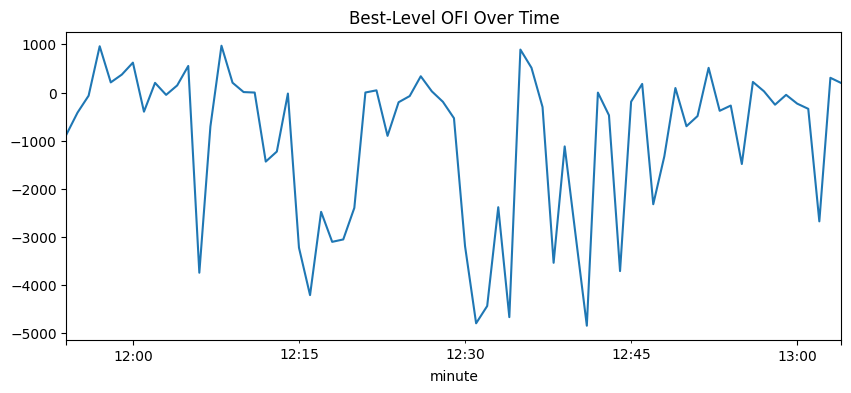

In [13]:
best_ofi = compute_best_level_ofi(df)
print("Best-Level OFI (1-min) Example:")
display(best_ofi.head())

best_ofi.set_index('minute')['Best_level_OFI'].plot(
    title='Best-Level OFI Over Time', figsize=(10, 4))

# Multi-Level OFI

Raw sum of OFIs across LOB levels 1–10, capturing deeper liquidity shifts.

Multi-Level OFI (1-min) Example:


,symbol,minute,Multi_level_OFI
0,AAPL,2024-10-21 11:54:00+00:00,253.0
1,AAPL,2024-10-21 11:55:00+00:00,3415.0
2,AAPL,2024-10-21 11:56:00+00:00,2346.0
3,AAPL,2024-10-21 11:57:00+00:00,2723.0
4,AAPL,2024-10-21 11:58:00+00:00,4736.0


<Axes: title={'center': 'Multi-Level OFI Over Time'}, xlabel='minute'>

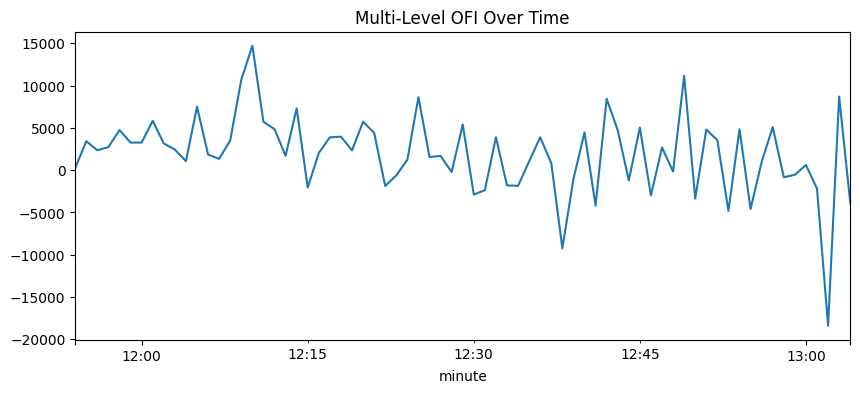

In [14]:
df_with_ofis, multi_ofi = compute_multi_level_ofi(df)
print("Multi-Level OFI (1-min) Example:")
display(multi_ofi.head())

multi_ofi.set_index('minute')['Multi_level_OFI'].plot(
    title='Multi-Level OFI Over Time', figsize=(10, 4))

# Integrated OFI

PCA-based projection of normalized multi-level OFIs for compact signal.

Integrated OFI (1-min) Example:


,symbol,ts_event,Integrated_OFI
0,AAPL,2024-10-21 11:54:00+00:00,-1.432279
1,AAPL,2024-10-21 11:55:00+00:00,-1.974856
2,AAPL,2024-10-21 11:56:00+00:00,-4.969174
3,AAPL,2024-10-21 11:57:00+00:00,0.618419
4,AAPL,2024-10-21 11:58:00+00:00,-2.150170


<Axes: title={'center': 'Integrated OFI Over Time (PCA Projection)'}, xlabel='ts_event'>

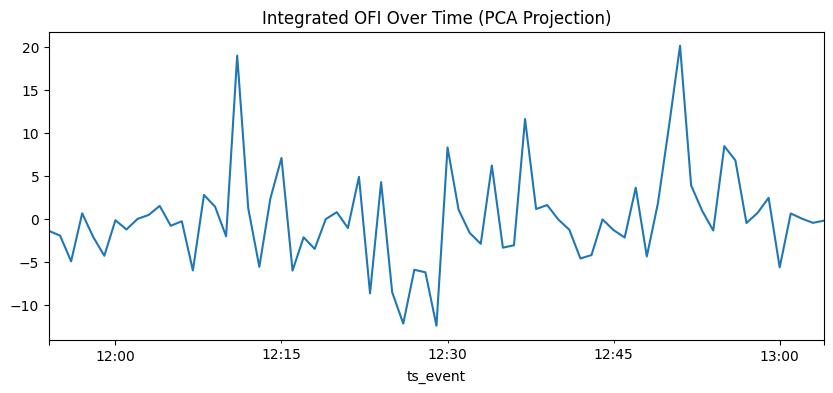

In [15]:
integrated_ofi = compute_integrated_ofi(df_with_ofis)
print("Integrated OFI (1-min) Example:")
display(integrated_ofi.head())

integrated_ofi.set_index('ts_event')['Integrated_OFI'].plot(
    title='Integrated OFI Over Time (PCA Projection)', figsize=(10, 4))

# Cross-Asset OFI

Lasso regression using simulated stocks OFIs to predict AAPL returns.

In [16]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Simulate 100 synthetic stocks
df_simulated = simulate_cross_asset_ofi(integrated_ofi, num_assets=100, noise_levels=0.5)

# Run Lasso
coefs, r2 = cross_asset_lasso(df_simulated)

# Display meaningful results
print(coefs)
non_zero_coefs = {k: v for k, v in coefs.items() if v != 0}
print(f"Non-zero coefficients: {len(non_zero_coefs)}")
print(non_zero_coefs)
print(f"R² score: {r2:.4f}")


{'AAPL': 0.0, 'STOCK_000': -0.0, 'STOCK_001': 0.0, 'STOCK_002': 0.0, 'STOCK_003': 0.0, 'STOCK_004': -0.0, 'STOCK_005': -0.0, 'STOCK_006': -0.0, 'STOCK_007': -0.0, 'STOCK_008': 0.0, 'STOCK_009': -0.0, 'STOCK_010': 0.0, 'STOCK_011': 0.0, 'STOCK_012': -0.0, 'STOCK_013': -0.0, 'STOCK_014': 0.0, 'STOCK_015': 0.0, 'STOCK_016': -0.019686735665319116, 'STOCK_017': -0.0, 'STOCK_018': -0.0, 'STOCK_019': -0.0, 'STOCK_020': -3.171692174809403, 'STOCK_021': -0.0, 'STOCK_022': -0.0, 'STOCK_023': 0.0, 'STOCK_024': 0.0, 'STOCK_025': 0.0, 'STOCK_026': 0.0, 'STOCK_027': -0.0, 'STOCK_028': -1.840646165078558, 'STOCK_029': -0.0, 'STOCK_030': -13.458473049031953, 'STOCK_031': -0.0, 'STOCK_032': -0.0, 'STOCK_033': 0.0, 'STOCK_034': 0.0, 'STOCK_035': 0.0, 'STOCK_036': -0.0, 'STOCK_037': -0.0, 'STOCK_038': -0.0, 'STOCK_039': 0.0, 'STOCK_040': 0.0, 'STOCK_041': -0.0, 'STOCK_042': -0.0, 'STOCK_043': -0.0, 'STOCK_044': 0.0, 'STOCK_045': -0.0, 'STOCK_046': -0.0, 'STOCK_047': -0.0, 'STOCK_048': -0.0, 'STOCK_049': 

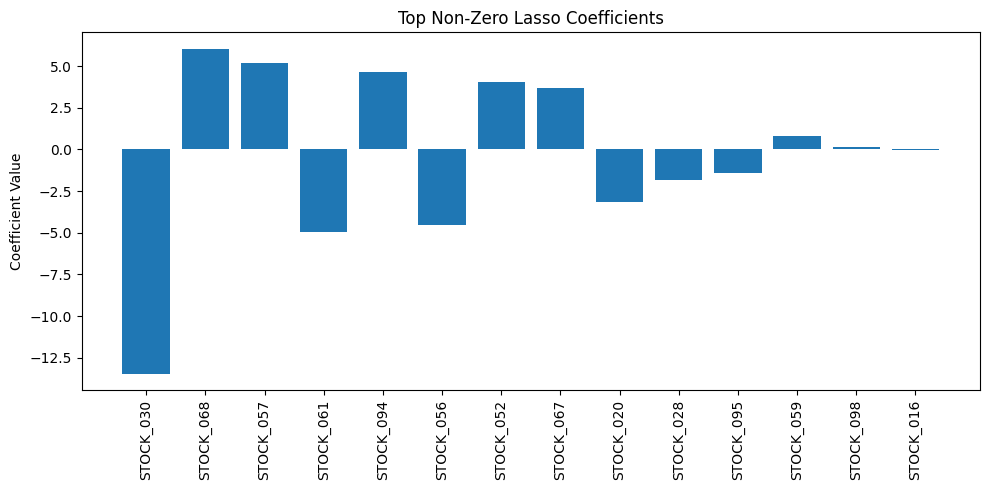

In [17]:
# Plot top non-zero Lasso coefficients
top_coefs = dict(sorted(non_zero_coefs.items(), key=lambda item: abs(item[1]), reverse=True))
plt.figure(figsize=(10, 5))
plt.bar(top_coefs.keys(), top_coefs.values())
plt.xticks(rotation=90)
plt.title("Top Non-Zero Lasso Coefficients")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()


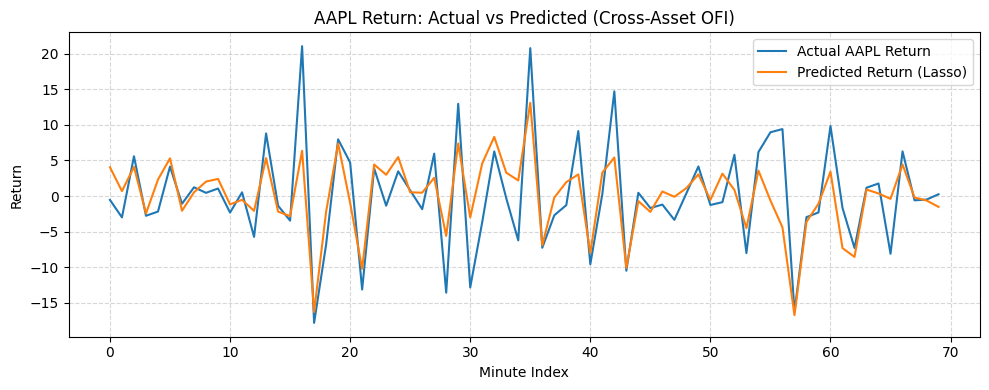

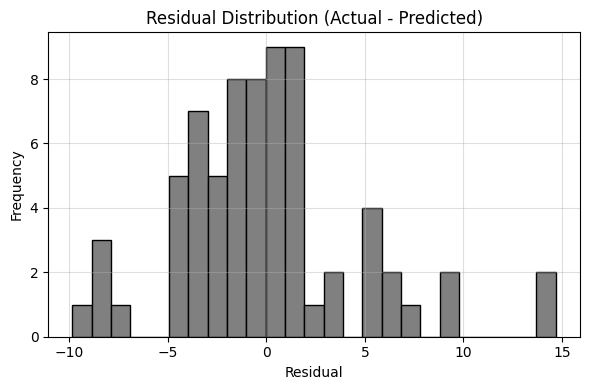

In [18]:
# Simulate cross-asset OFI with custom number of synthetic stocks
# df_simulated = simulate_cross_asset_ofi(integrated_ofi, num_assets=100, noise_levels=0.5)

# Get all numeric features except the target
feature_cols = [col for col in df_simulated.select_dtypes(include=[np.number]).columns if col != 'return_AAPL']
X = df_simulated[feature_cols].values
y = df_simulated['return_AAPL'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Lasso
lasso = LassoCV(cv=5, random_state=0, max_iter=5000).fit(X_scaled, y)

# Predict
y_pred = lasso.predict(X_scaled)

# Plot: Actual vs Predicted Returns
plt.figure(figsize=(10, 4))
plt.plot(y, label='Actual AAPL Return', linewidth=1.5)
plt.plot(y_pred, label='Predicted Return (Lasso)', linewidth=1.5)
plt.title("AAPL Return: Actual vs Predicted (Cross-Asset OFI)")
plt.xlabel("Minute Index")
plt.ylabel("Return")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot: Residuals Histogram
residuals = y - y_pred
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=25, color='gray', edgecolor='black')
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
